In [2]:
# Gradient Boosting
!pip install xgboost

   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ----- ---------------------------------- 9.4/72.0 MB 55.0 MB/s eta 0:00:02
   ------------ --------------------------- 23.3/72.0 MB 62.1 MB/s eta 0:00:01
   --------------------- ------------------ 38.0/72.0 MB 65.5 MB/s eta 0:00:01
   ---------------------------- ----------- 52.2/72.0 MB 66.4 MB/s eta 0:00:01
   ------------------------------------- -- 67.9/72.0 MB 68.1 MB/s eta 0:00:01
   ---------------------------------------  71.8/72.0 MB 68.3 MB/s eta 0:00:01
   ---------------------------------------- 72.0/72.0 MB 51.1 MB/s eta 0:00:00


In [1]:
import pandas as pd
import numpy as np

# Logistic regression and evaluation
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, accuracy_score, roc_curve

# Random forest
from sklearn.ensemble import RandomForestClassifier
#cross Validation
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Gradient Boosting
import xgboost as xgb
from xgboost import XGBClassifier

import statsmodels.api as sm

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
inpatient_df= pd.read_csv('sparcs_inpatient_derived.csv' , encoding="ISO-8859-1")

In [3]:
inpatient_df

,service_area,county,facility_id,age_group,zip_code,gender,race,ethnicity,length_of_stay,type_of_admission,...,procedure_code,drug_code,mdc_code,severity_code,mortality_risk,surgical_description,payment_typology,clinical_score,combined_score,readmitted
0,New York City,Bronx,1169,70+,104,M,Other Race,Spanish/Hispanic,27,Emergency,...,OTR004,137,4,3,4,Medical,Medicare,0.8455,0.852820,1
1,New York City,Bronx,1168,18 to 29,104,F,Other Race,Spanish/Hispanic,2,Emergency,...,PGN003,540,14,1,1,Surgical,Medicaid,0.2280,0.241156,0
2,New York City,Bronx,3058,70+,104,M,Other Race,Spanish/Hispanic,5,Emergency,...,ADM017,463,11,3,3,Medical,Medicare,0.7720,0.718673,0
3,New York City,Bronx,1169,50 to 69,104,F,Black/African American,Not Span/Hispanic,3,Emergency,...,CNS002,58,1,2,1,Medical,Medicare,0.4645,0.370982,0
4,New York City,Bronx,3058,50 to 69,105,M,Other Race,Spanish/Hispanic,6,Emergency,...,IMG007,813,21,3,2,Medical,Private Health Insurance,0.7045,0.582810,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1521583,Hudson Valley,Rockland,776,30 to 49,109,F,Multi-racial,Not Span/Hispanic,5,Emergency,...,CNS002,50,1,2,2,Medical,Medicare,0.5520,0.417391,0
1521584,Long Island,Suffolk,913,70+,117,F,White,Not Span/Hispanic,3,Emergency,...,MST010,308,8,2,3,Surgical,Medicare,0.5035,0.512826,0
1521585,Long Island,Suffolk,913,70+,117,M,White,Not Span/Hispanic,7,Emergency,...,MST023,951,11,3,3,Surgical,Medicare,0.6220,0.568321,0
1521586,Long Island,Suffolk,913,70+,117,M,White,Not Span/Hispanic,3,Emergency,...,ESA001,206,5,3,3,Medical,Medicare,0.7600,0.642312,0


In [4]:
inpatient_df.columns

Index(['service_area', 'county', 'facility_id', 'age_group', 'zip_code',
       'gender', 'race', 'ethnicity', 'length_of_stay', 'type_of_admission',
       'patient_disposition', 'diagnosis_code', 'procedure_code', 'drug_code',
       'mdc_code', 'severity_code', 'mortality_risk', 'surgical_description',
       'payment_typology', 'clinical_score', 'combined_score', 'readmitted'],
      dtype='object')

In [5]:
selected_features = [
    'severity_code', 'mortality_risk', 'mdc_code',
    'type_of_admission', 'length_of_stay',
    'age_group', 'gender', 'race', 'ethnicity',
    'service_area', 'payment_typology'
]

In [6]:
X = inpatient_df[selected_features]
y = inpatient_df['readmitted']

In [7]:
#Encoding categorical variables
X = pd.get_dummies(
    X,
    columns=[
        'type_of_admission', 'age_group', 'gender', 'race', 'ethnicity',
        'service_area', 'payment_typology'
    ],
    drop_first=True
)

In [8]:
X.shape

(1521588, 36)

In [9]:
X.head()

,severity_code,mortality_risk,mdc_code,length_of_stay,type_of_admission_Emergency,type_of_admission_Newborn,type_of_admission_Not Available,type_of_admission_Trauma,type_of_admission_Urgent,age_group_18 to 29,...,service_area_Southern Tier,service_area_Western NY,payment_typology_Department of Corrections,payment_typology_Federal/State/Local/VA,"payment_typology_Managed Care, Unspecified",payment_typology_Medicaid,payment_typology_Medicare,payment_typology_Miscellaneous/Other,payment_typology_Private Health Insurance,payment_typology_Self-Pay
0,3,4,4,27,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,1,1,14,2,True,False,False,False,False,True,...,False,False,False,False,False,True,False,False,False,False
2,3,3,11,5,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
3,2,1,1,3,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,3,2,21,6,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False


In [10]:
#partition data
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

train_X.shape, test_X.shape, train_y.shape, test_y.shape

((1065111, 36), (456477, 36), (1065111,), (456477,))

**Logistic Regression**

In [11]:
# fit a logistic regression (set penalty=l2 and C=1e42 to avoid regularization)
# Initialize model
logreg = LogisticRegression(max_iter=2000, solver='lbfgs')

In [12]:
# Fit the model
logreg.fit(train_X, train_y)

LogisticRegression(max_iter=2000)

In [13]:
#now make prediction
pred_y = logreg.predict(test_X)

In [14]:
#predicted probability
pred_y_prob = logreg.predict_proba(test_X)[:, 1]

In [15]:
print('intercept ', logreg.intercept_[0])

intercept  -15.636013909275155


In [16]:
#coefficients to odd numbers

coef_df = pd.DataFrame({
    'Feature': train_X.columns,
    'Coefficient': logreg.coef_[0],
    'Odds_Ratio': np.exp(logreg.coef_[0])
})

# Sort by largest effect
coef_df_sorted = coef_df.sort_values(by='Odds_Ratio', ascending=False)
coef_df_sorted

,Feature,Coefficient,Odds_Ratio
5,type_of_admission_Newborn,3.461749,31.872668
1,mortality_risk,2.114893,8.288697
0,severity_code,1.857277,6.406267
4,type_of_admission_Emergency,1.172343,3.229551
6,type_of_admission_Not Available,0.859407,2.361759
8,type_of_admission_Urgent,0.651794,1.918981
25,service_area_New York City,0.546189,1.726661
24,service_area_Long Island,0.523484,1.687898
21,service_area_Central NY,0.264010,1.302142
19,ethnicity_Spanish/Hispanic,0.262985,1.300807


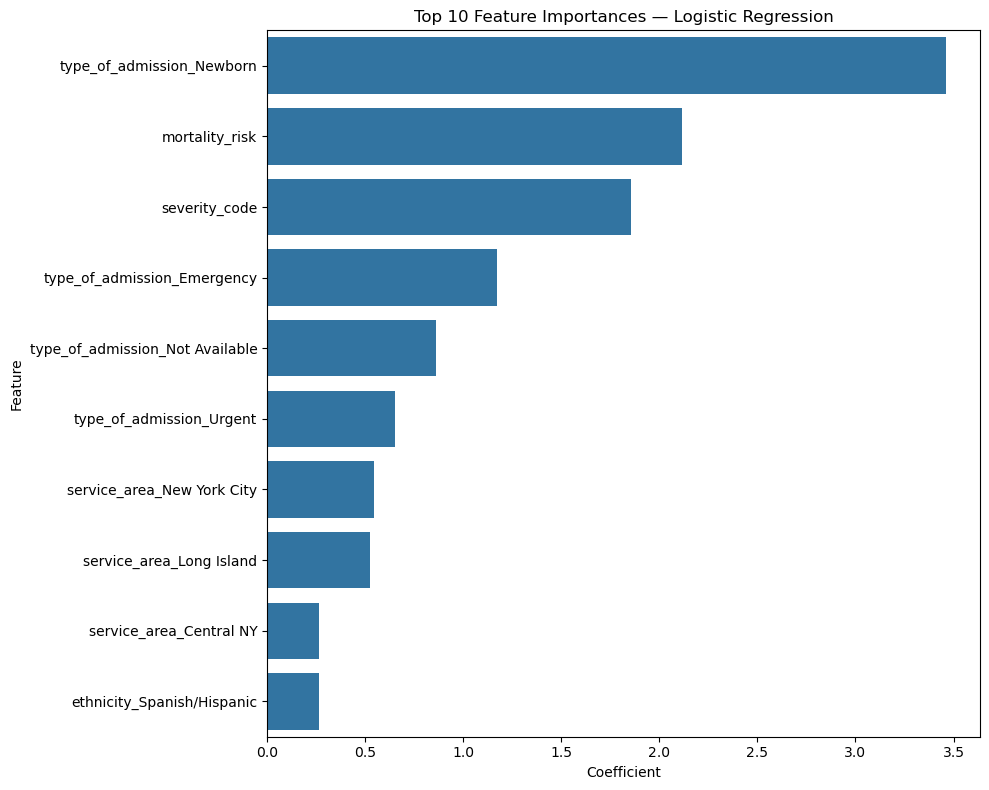

In [33]:
plt.figure(figsize=(10,8))
sns.barplot(y="Feature", x="Coefficient", data=coef_df_sorted.head(10))
plt.title("Top 10 Feature Importances — Logistic Regression")
plt.tight_layout()
plt.show()

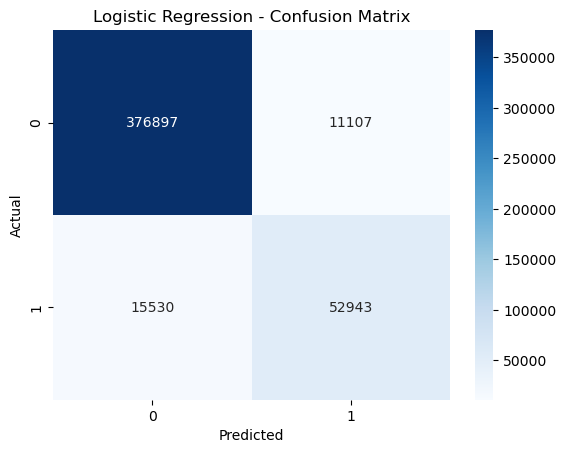

In [17]:
#confusion matrix

cm = confusion_matrix(test_y, pred_y)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression - Confusion Matrix')
plt.show()

In [18]:
from sklearn.metrics import classification_report

print(classification_report(test_y, pred_y))

              precision    recall  f1-score   support

           0       0.96      0.97      0.97    388004
           1       0.83      0.77      0.80     68473

    accuracy                           0.94    456477
   macro avg       0.89      0.87      0.88    456477
weighted avg       0.94      0.94      0.94    456477



In [19]:
#

roc_auc = roc_auc_score(test_y, pred_y_prob)
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9774819746283848


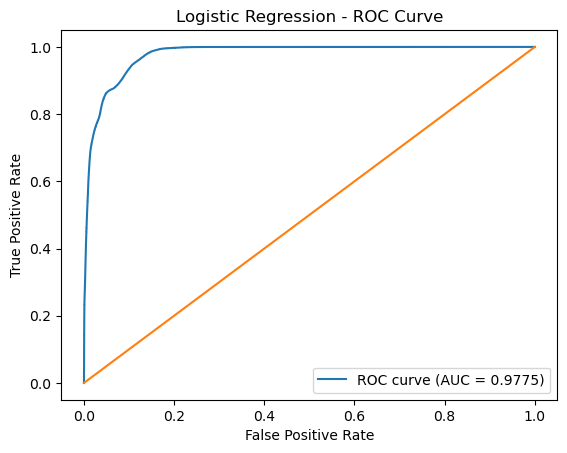

In [20]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(test_y, pred_y_prob)

plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='-')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression - ROC Curve')
plt.legend()
plt.show()

**Random Forest**

In [21]:
#baseline model

rf = RandomForestClassifier(
    n_estimators=300,  #Number of trees in the forest
    max_depth=None, #Max depth of the tree
    min_samples_split=2, #Min number of samples required to split a node
    min_samples_leaf=1, #Min number of samples required at a leaf node
    class_weight="balanced", #Handling imbalanced nature of dataset
    random_state=42,
    n_jobs=-1
)

rf.fit(train_X, train_y)

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

In [22]:
#prediction

pred_y = rf.predict(test_X)
prob_y = rf.predict_proba(test_X)[:,1]

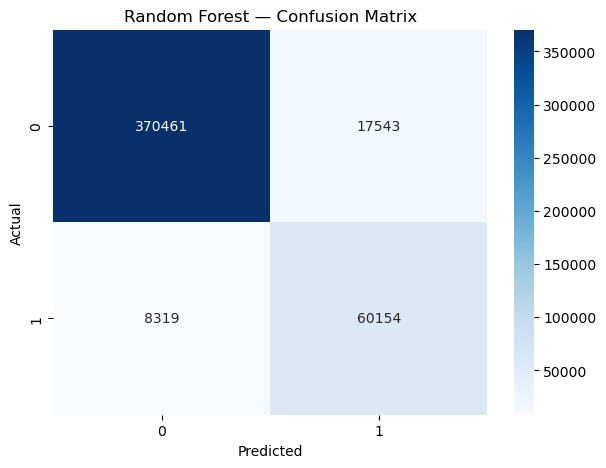

In [23]:
#confusion Matrix
cm = confusion_matrix(test_y, pred_y)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [24]:
print(classification_report(test_y, pred_y))

              precision    recall  f1-score   support

           0       0.98      0.95      0.97    388004
           1       0.77      0.88      0.82     68473

    accuracy                           0.94    456477
   macro avg       0.88      0.92      0.89    456477
weighted avg       0.95      0.94      0.94    456477



In [25]:
auc = roc_auc_score(test_y, prob_y)
print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.9823476048934706


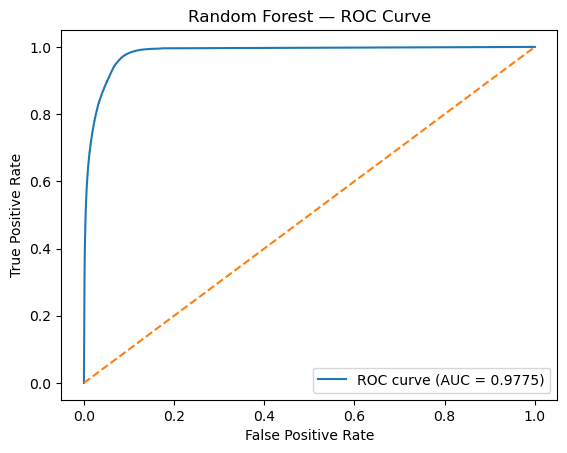

In [26]:
fpr, tpr, _ = roc_curve(test_y, prob_y)

plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest — ROC Curve")
plt.legend()
plt.show()

In [27]:
#feature importance

importances = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values(by="importance", ascending=False)

importances

,feature,importance
1,mortality_risk,0.372850
0,severity_code,0.309036
2,mdc_code,0.115503
3,length_of_stay,0.094965
4,type_of_admission_Emergency,0.030068
32,payment_typology_Medicare,0.008651
12,age_group_70+,0.008361
13,gender_M,0.006393
5,type_of_admission_Newborn,0.005883
11,age_group_50 to 69,0.004323


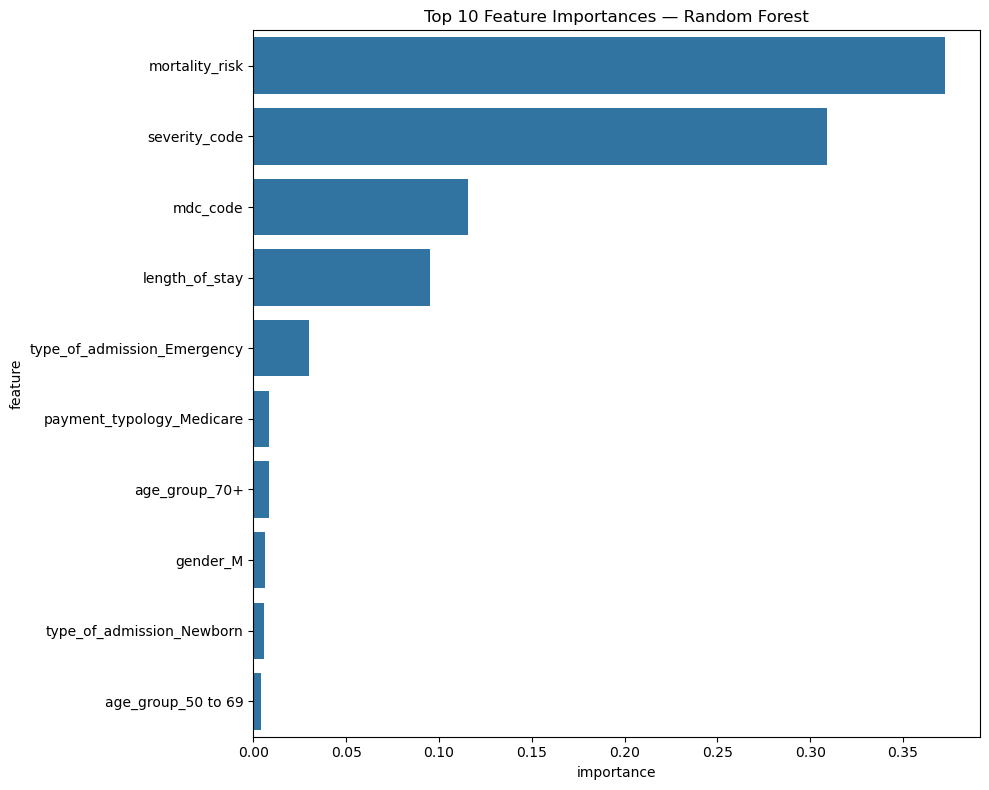

In [28]:
plt.figure(figsize=(10,8))
sns.barplot(y="feature", x="importance", data=importances.head(10))
plt.title("Top 10 Feature Importances — Random Forest")
plt.tight_layout()
plt.show()

In [34]:
#Cross Validation using KFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

auc_scores = cross_val_score(
    rf, X, y,
    cv=skf,
    scoring="roc_auc",
    n_jobs=-1
)

print("AUC Scores:", auc_scores)
print("Mean AUC:", auc_scores.mean())

AUC Scores: [0.9824002  0.98232742 0.98231006 0.98223875 0.98266706]
Mean AUC: 0.982388698807331


**Extreme Gradient Boost (XGBoost)**

In [40]:
# Train XGBoost model
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(train_X, train_y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [41]:
# Predictions
pred_y = xgb.predict(test_X)
proba_y = xgb.predict_proba(test_X)[:, 1]

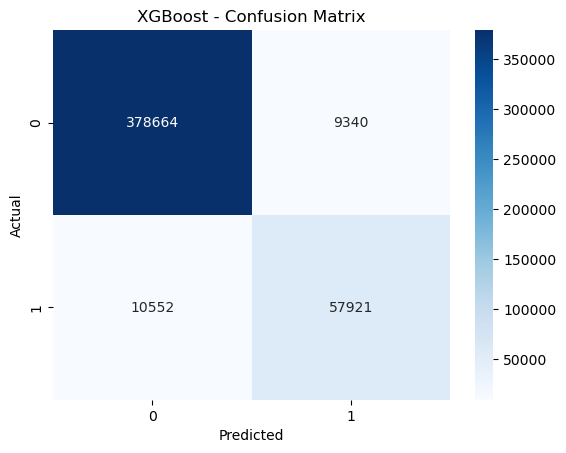

In [42]:
cm = confusion_matrix(test_y, pred_y)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [43]:
# Metrics
accuracy = accuracy_score(test_y, pred_y)
auc = roc_auc_score(test_y, proba_y)

print("XGBoost Accuracy:", accuracy)
print("XGBoost ROC-AUC:", auc)
print(classification_report(test_y, pred_y))

XGBoost Accuracy: 0.9564227770511986
XGBoost ROC-AUC: 0.9890695942629313
              precision    recall  f1-score   support

           0       0.97      0.98      0.97    388004
           1       0.86      0.85      0.85     68473

    accuracy                           0.96    456477
   macro avg       0.92      0.91      0.91    456477
weighted avg       0.96      0.96      0.96    456477



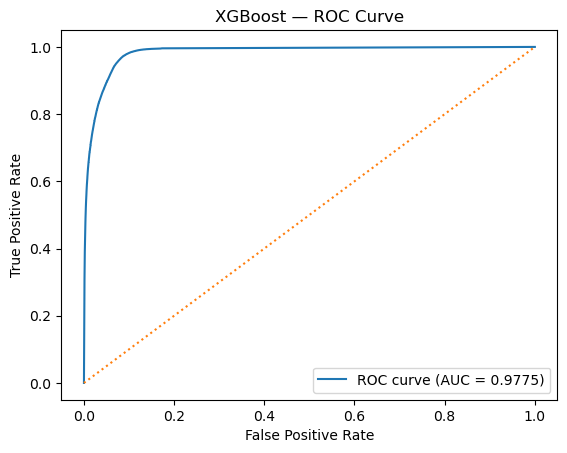

In [44]:
fpr, tpr, _ = roc_curve(test_y, prob_y)

plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0,1],[0,1], linestyle=':')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost — ROC Curve")
plt.legend()
plt.show()

In [45]:
#feature importance

importance = xgb.get_booster().get_score(importance_type='gain')
importance = dict(sorted(importance.items(), key=lambda x: x[1], reverse=True))


In [46]:
feat_imp = pd.DataFrame({
    'feature': list(importance.keys()),
    'importance': list(importance.values())
})

feat_imp = feat_imp.sort_values(by="importance", ascending=False)
feat_imp

,feature,importance
0,mortality_risk,1965.711304
1,severity_code,655.607056
2,mdc_code,101.970299
3,type_of_admission_Newborn,96.914818
4,type_of_admission_Emergency,26.526222
5,service_area_New York City,17.328711
6,service_area_Long Island,17.266367
7,length_of_stay,11.310521
8,type_of_admission_Urgent,9.860985
9,payment_typology_Medicare,8.328803


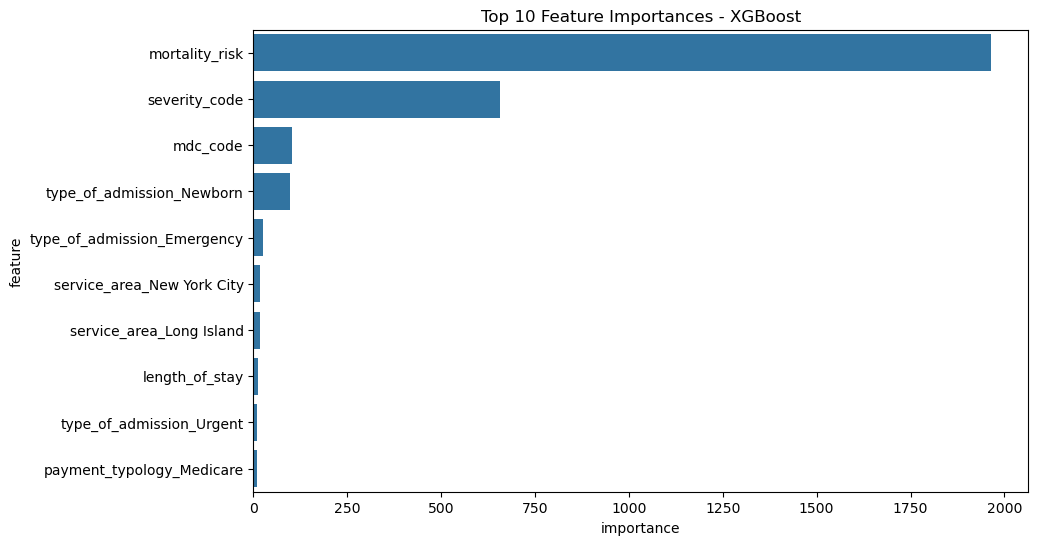

In [47]:
plt.figure(figsize=(10,6))
sns.barplot(data=feat_imp.head(10), x="importance", y="feature")
plt.title("Top 10 Feature Importances - XGBoost")
plt.show()

In [48]:
#cross validation

cv_auc = cross_val_score(
    xgb, X, y, 
    cv=5, 
    scoring='roc_auc', 
    n_jobs=-1
)

print("AUC scores:", cv_auc)
print("Mean AUC:", cv_auc.mean())

AUC scores: [0.98976598 0.98964854 0.98873448 0.98817709 0.98844244]
Mean AUC: 0.9889537053742303
